In [ ]:
!pip install transformers -q

In [ ]:
import json
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import ast

with open('vacancies_details.json', 'r', encoding='utf-8') as f:
  vacancies = json.load(f)

#Удаляем дублирующиеся строки по ссылке и вакансии без массива навыков
vac_df = pd.DataFrame(vacancies)
vac_df['id'] = vac_df['link'].apply(lambda x:x.split('/')[-1].split('?')[0])
vac_df = vac_df.drop_duplicates(subset=['id'])
vac_df = vac_df[vac_df['skills'].apply(lambda x:len(x) > 0)]

repos_df = pd.read_excel('repos_filtered.xlsx')

In [ ]:
vac_df.shape

(3364, 8)

In [83]:
from collections import Counter

def lang_bytes_dicts_to_list(langs):
  #Может быть nan в значениях
  if isinstance(langs, str):
    langs = dict(ast.literal_eval(langs))
    return [(x, langs[x]) for x in langs]

#Проходимся по всех языкам для пользователя и считаем суммарный байткод, после этого формируем список скилов
def lang_bytes_to_skills(langs):
    dct = {}
    result_skills = []
    sm_bytes = 0

    #Может быть nan в значениях
    for l in langs:
      if isinstance(l, tuple):
        if l[0] in dct:
          dct[l[0]] += l[1]
        else:
          dct[l[0]] = l[1]

        sm_bytes += l[1]

    #Взял только те языки, на которых больше 5% кода, чтобы убрать всякий мусор
    for key in dct.keys():
      dct[key] = round(100*dct[key]/sm_bytes, 2)
      if dct[key]>5:
        result_skills.append(key)

    if "Jupyter Notebook" in result_skills:
      result_skills.append("ML")

    return result_skills

repos_df["lang_list"] = repos_df["lang_bytes"].apply(lang_bytes_dicts_to_list)
exploded_repos = repos_df.explode("lang_list")

#Из словарей байткодов, превращаем языки в список навыков
users_skills_df = exploded_repos.groupby("owner_login").agg(lang_list=("lang_list", list))
users_skills_df["skills"] = users_skills_df["lang_list"].apply(lambda x:lang_bytes_to_skills(x))
users_skills_df = users_skills_df.reset_index()
users_skills_df = users_skills_df[users_skills_df['skills'].apply(lambda x:len(x)>0)]
users_skills_df

,owner_login,lang_list,skills
0,0xPh0enix,"[(C#, 89478), (C++, 6052), (C, 94), (C++, 1233...","[C#, C++]"
1,1111alexandrr,"[nan, (Go, 12613941), (C, 673780), (JavaScript...","[Go, Rust]"
2,20jeka08,"[(HTML, 12), (Jupyter Notebook, 1160213), (Pyt...","[Jupyter Notebook, C, C++, ML]"
3,3333alexandr,"[(Python, 25960), (Go, 12613941), (C, 673780),...",[Go]
4,AGaevskiy,"[nan, (C++, 45746), (C, 28653), (CMake, 12294)...","[C++, C, CMake, PHP]"
...,...,...,...
408,zamtmn,"[(Pascal, 1266188), (C++, 7247), (Batchfile, 6...",[Pascal]
409,zapletnev,"[nan, (Java, 5006), (Fantom, 3238), (Shell, 13...","[MATLAB, HTML]"
410,zbx-sadman,"[(C++, 21099), (C, 2897), nan, (C++, 132177), ...","[C++, C, PowerShell, Perl]"
411,zeegin,"[(Python, 2459), (Batchfile, 295), (C++, 7344)...","[Python, JavaScript, 1C Enterprise, TypeScript]"


In [ ]:
model = SentenceTransformer('Nashhz/SBERT_KFOLD_Job_Descriptions_to_Skills')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
#Превращаем в вектора скиллы с гитхаба и вакансий, описания вакансий.
#Так как по документации модели, она не видела в процессе обучения меньше 7 токенов на описании и меньше 4 токенов на навыках, то
#Сделаем так чтобы при мэтчинге описания с навыками разработчика у нас длина 'предложения с навыками' была не меньше 4 токенов
#Длина навыков вакансий при мэтчинге с навыками c гитахаба будет не меньше 7 токенов
skills_embedings = []

for idx, (_, row) in enumerate(users_skills_df.iterrows()):
  skills_embedings.append({})
  txt = f"Навыки разработчика c Github: {", ".join(row["skills"])}"
  skills_embedings[idx]["skills_vector"] = model.encode(txt, convert_to_tensor=True)
  skills_embedings[idx]["login"] = row["owner_login"]
  skills_embedings[idx]["skills"] = row["skills"]


vac_embedings = []

for idx, (_, row) in enumerate(vac_df.iterrows()):
  vac_embedings.append({})
  txt = f"Список ключевых навыков, которые содержатся в вакансии: {", ".join(row["skills"])}"
  vac_embedings[idx]["skills_vector"] = model.encode(txt, convert_to_tensor=True)
  vac_embedings[idx]["desc_vector"] = model.encode(row["description"], convert_to_tensor=True)
  vac_embedings[idx]["description"] = row["description"]
  vac_embedings[idx]["link"] = row["link"]
  vac_embedings[idx]["skills"] = row["skills"]

In [ ]:
from sentence_transformers import util


def matching(vac_embedings, skills_embedings):
  matched_data=[]

  #Используем встроенный метод для косинусного сходства эмбедингов, util.cos_sim() возвращает значения в диапозоне [-1,1]
  #Далее сведем этот диапозон к [0,1], чтобы в итоге получился интерпретируемый результат
  for _, vac in enumerate(vac_embedings):
    for _, skills in enumerate(skills_embedings):
      skills_score = util.cos_sim(vac["skills_vector"], skills["skills_vector"]).item()
      desc_score = util.cos_sim(vac["desc_vector"], skills["skills_vector"]).item()
      score = 0.5*skills_score + 0.5*desc_score

      matched_data.append({
          "login":skills["login"],
          "link":vac["link"],
          "description":vac["description"],
          "score":score,
          "vacancy_skills":vac["skills"],
          "git_skills":skills["skills"]
      })

  return matched_data

#Функция для приведения score к примелимому виду в диапозоне [0,1]
#Сделаем min-max scaling и возведем в квадрат чтобы сделать больше разницу между значениями
#Так как диапозон значений примерно (0,1, 0,7), то нам нужно растянуть значения
def scaling_scores(matched_data):
  mx, mn = float("-inf"), float("inf")

  for item in matched_data:
    mn = min(mn, item["score"])
    mx = max(mx, item["score"])

  for item in matched_data:
    item["score"] = ((item["score"]-mn)/(mx-mn))**2

  return matched_data

matched_data = matching(vac_embedings, skills_embedings)
matched_data = scaling_scores(matched_data)
matched_data[0]

{'login': '0xPh0enix',
 'link': 'https://hh.ru/vacancy/131058426?query=python+%D1%80%D0%B0%D0%B7%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D1%87%D0%B8%D0%BA&hhtmFrom=vacancy_search_list',
 'description': 'Рассматриваются вакансии только с фотографиями (или прикрепляйте в сопроводительных сообщениях) Обязанности Разработка и поддержка backend-сервисов на FastAPI Проектирование и оптимизация баз данных PostgreSQL, работа с SQLAlchemy и Alembic. Интеграция очередей сообщений (RabbitMQ и Kafka) Требования Коммерческий опыт Python от 5-6 лет, уверенное владение FastAPI Понимание микросервисной архитектуры, асинхронности Опыт с Redis-кэшированием или высоконагруженными системами Будет плюсом Опыт разработки на фронтах (Vue / React) Опыт разработки на других языках (Rust / Java / Node) Использование ИИ-инструментов для разработки Опыт работы протокола Modbus для опроса IoT-устройств и промышленных датчиков',
 'score': 0.4003632565758902,
 'vacancy_skills': ['Python',
  'GitHub',
  'Gitlab',
  'FastAPI',


In [ ]:
output_df = pd.DataFrame(matched_data)
np.round(output_df.describe(),2)

,score
count,1342236.00
mean,0.32
std,0.10
min,0.00
25%,0.26
50%,0.32
75%,0.38
max,1.00


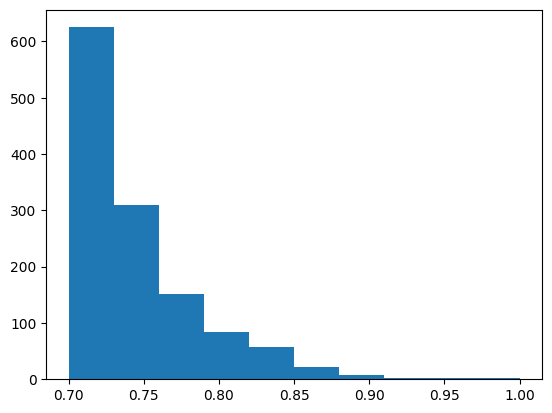

In [ ]:
import matplotlib.pyplot as plt

plt.hist(output_df[output_df['score']>0.7]["score"])
plt.show();

In [ ]:
output_df.to_csv("matched_df.csv", index=False)